# Notebook 4. Non-linear exploration

**The question.** Is the link between the kernel numbers (`A_t`, `S_t`, `R_t`) and the grokking step a straight line, or is it curved? And which of the three numbers governs it?

Notebook 3 hinted that curved models do better. Here we look closely. The main tool is **kernel ridge regression**: it draws a smooth curved surface through the data, with no shape fixed in advance. We line it up against simpler models, so we can see what the curve adds.

**Short answer.**
- **Yes, it's curved.** On hidden cells a straight line explains 34% of the spread in log `T`. Curved models explain 53% to 56%.
- **The curves mostly add up.** Letting the numbers interact (kernel ridge, products) adds nothing over one curve per number.
- **`R_t` governs it most.** Taking it out drops kernel ridge from 53% to 30%. `A_t` and `S_t` matter less.
- **The settings govern the numbers.** Weight decay sets `S_t`, and width and `alpha` set `R_t`.

### Words you need

| Word | What it means |
| --- | --- |
| grokked | The test accuracy reached 0.95. The **grokking step** `T` is the first step where that happens (report §3.5). |
| cell | One mix of `alpha`, width and weight decay. Each cell has 5 seeds. |
| `S_t`, `R_t`, `A_t` | How much the kernel has grown, how much it has turned, and how well it lines up with the labels, all read at step 2,430 (report Eq. 6). |
| R² | The share of the spread in log `T` the model explains on held-out runs. 1 is perfect. 0 is no better than guessing the average. Below 0 is worse than that. |
| concordance | Pick two runs. How often does the model say the right one groks first? 0.5 is a coin toss and 1 is perfect. |
| additive | Each number gets its own curve, and the curves are added up. No number changes the effect of another. |
| interaction | The effect of one number depends on the value of another. |

**Which runs.** Kernel ridge predicts a number, log `T`, so it needs runs with a known `T`. We use the 355 runs that grokked, out of 630 with weight decay up to 1e-3. Notebook 3's XGBoost covers the runs that never grok.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import partial_dependence
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline, make_union
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler

plt.style.use('fitting.mplstyle')
GREY, INK = '#8a8984', '#0b0b0b'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06'}
ALPHA_COLOURS = {0.5: '#2a78d6', 1.0: '#0b0b0b', 2.0: '#eb6834'}
kernel = ['A_t', 'S_t', 'R_t']
pairs = [('A_t', 'S_t'), ('A_t', 'R_t'), ('S_t', 'R_t')]
LANDMARK = 2_430

## Load the data

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

events = runs.set_index('run_id')
events['T'] = acc[acc['test_acc'] >= 0.95].groupby('run_id')['step'].min()
events = events.reset_index()
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

everything = events.merge(kern[kern['step'] == LANDMARK].drop(columns='step'), on='run_id')
everything = everything[everything['eta_kappa'] <= 1e-3].reset_index(drop=True)
data = everything.dropna(subset=['T']).reset_index(drop=True)     # grokked runs only
log_T = np.log(data['T'])
assert data['T'].min() > LANDMARK
data.groupby('alpha').size().rename('grokked runs')

alpha
0.5    178
1.0    130
2.0     47
Name: grokked runs, dtype: int64

## Part 1. Look before modelling

Each dot is a grokked run, coloured by `alpha`. If the link were a straight line, each cloud would look like a tilted band.

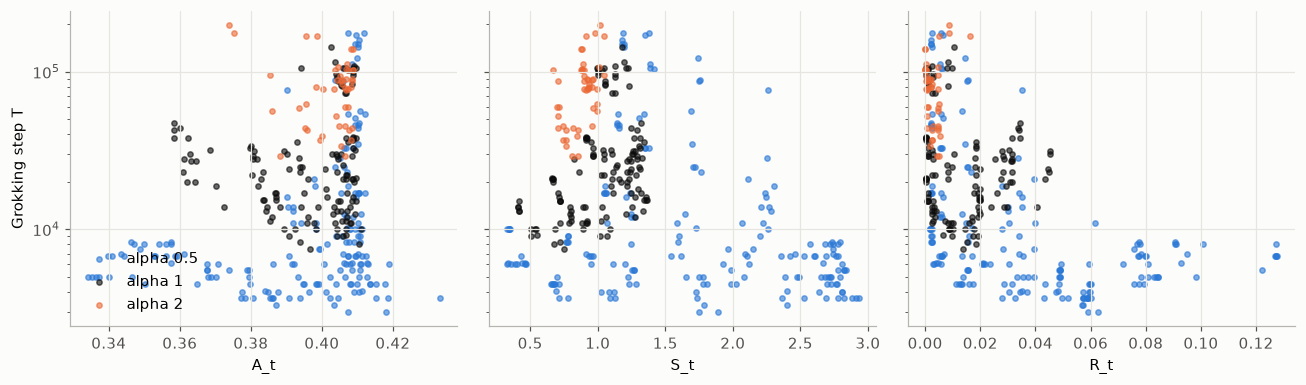

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, number in zip(axes, kernel):
    for a, g in data.groupby('alpha'):
        ax.scatter(g[number], g['T'], s=12, color=ALPHA_COLOURS[a], alpha=0.6, label=f'alpha {a:g}')
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Grokking step T')
axes[0].legend(loc='lower left')
plt.tight_layout()
plt.show()

**Takeaway**
- Each `alpha` sits in its own patch. `alpha` 2 (orange) bunches at small `S_t` and `R_t` and groks late. `alpha` 0.5 (blue) spreads wide and groks early.
- The clouds don't look like straight bands. `R_t` drops steeply near 0 and then flattens.

## Part 2. Is it curved? A ladder of four models

Each step up the ladder allows one more kind of shape.

1. **Linear**: a flat surface. One slope per number.
2. **Linear + pairs**: adds the squares and the products of two numbers. Gentle bends and simple interactions.
3. **Additive splines**: a free curve for each number, added up. Any bend, but no interactions.
4. **Splines + pair products**: the curves of step 3 plus the product of each pair of numbers.
5. **Kernel ridge**: any smooth surface, with interactions allowed.

If 3 beats 1, the link is curved. If 4 or 5 beats 3, the numbers also interact.

We test each model in two ways:
- **Hide one cell.** The model has seen runs like these, so this tests the shape.
- **Hide one `alpha`.** The model has to reach a new kind of run, as in notebook 3.

Kernel ridge has two knobs: how smooth the surface is, and how much it is pulled toward flat. We pick them inside the training runs, holding out whole cells, so the hidden runs are never used to tune. Kernel ridge also has no built-in average: far from the data its prediction falls to 0. So we subtract the average log `T` before fitting and add it back after.

In [4]:
models = {
    'linear': lambda: make_pipeline(StandardScaler(), LinearRegression()),
    'linear + pairs': lambda: make_pipeline(StandardScaler(), PolynomialFeatures(2), RidgeCV(np.logspace(-3, 3, 13))),
    'additive splines': lambda: make_pipeline(StandardScaler(), SplineTransformer(n_knots=5, degree=3), RidgeCV(np.logspace(-3, 3, 13))),
    'splines + pair products': lambda: make_pipeline(StandardScaler(), make_union(SplineTransformer(n_knots=5, degree=3),
                                                     PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                                     RidgeCV(np.logspace(-3, 3, 13))),
    'kernel ridge': lambda: TransformedTargetRegressor(
        GridSearchCV(make_pipeline(StandardScaler(), KernelRidge(kernel='rbf')),
                     {'kernelridge__alpha': [0.01, 0.1, 1], 'kernelridge__gamma': [0.1, 0.5, 2]}, cv=GroupKFold(5)),
        transformer=StandardScaler()),
}

pred = {}
for hide in ['cell', 'alpha']:
    for name, make in models.items():
        p = pd.Series(index=data.index, dtype=float)
        for group in data[hide].unique():
            train, test = data[hide] != group, data[hide] == group
            model = make()
            if name == 'kernel ridge':
                model.fit(data.loc[train, kernel], log_T[train], groups=data.loc[train, 'cell'])
            else:
                model.fit(data.loc[train, kernel], log_T[train])
            p[test] = model.predict(data.loc[test, kernel])
        pred[hide, name] = p

### Hide one cell

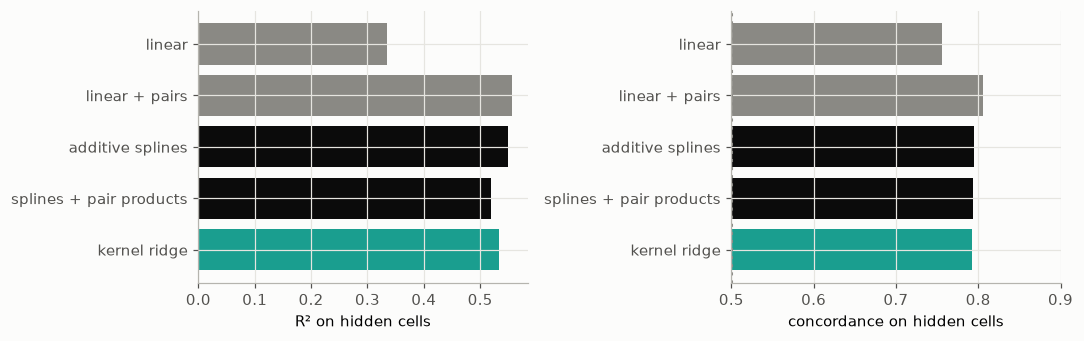

,R²,concordance
linear,0.335,0.756
linear + pairs,0.556,0.806
additive splines,0.549,0.795
splines + pair products,0.520,0.794
kernel ridge,0.533,0.792


In [5]:
scores = pd.DataFrame({name: {'R²': r2_score(log_T, pred['cell', name]), 'concordance': concordance_index(log_T, pred['cell', name])}
                       for name in models}).T

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
colours = [GREY, GREY, INK, INK, KERNEL_COLOURS['S_t']]
for ax, col in zip(axes, scores):
    ax.barh(scores.index, scores[col], color=colours)
    ax.invert_yaxis()
    ax.set_xlabel(col + ' on hidden cells')
axes[1].set_xlim(0.5, 0.9)
axes[1].axvline(0.5, color=GREY, linestyle=':')
plt.tight_layout()
plt.show()
scores.round(3)

**Takeaway**
- The straight line explains 34% (R² 0.335). Every curved model explains 52% to 56%. **So the link is curved.**
- The additive splines (0.549) do as well as kernel ridge (0.533) and better than splines with pair products (0.520). **Interactions add nothing once each number has its own curve.**
- Linear + pairs (0.556) does well too, because its squared terms are gentle curves.

### Hide one `alpha`

We score each hidden `alpha` on its own. R² over all three is also shown. It measures whether the model gets the actual step right, and the ranking alone doesn't need that.

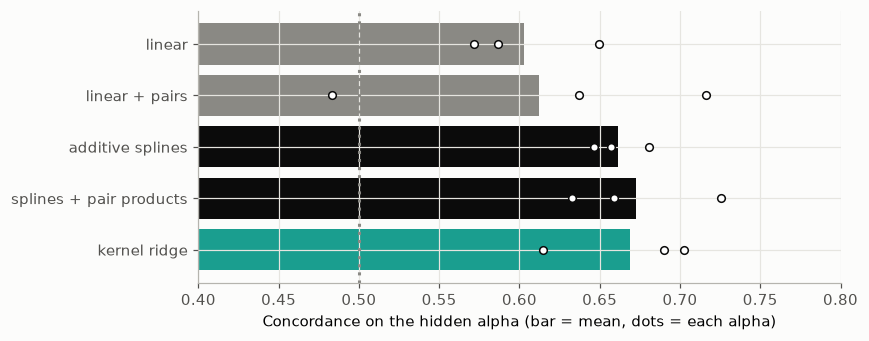

,alpha 0.5,alpha 1,alpha 2,mean concordance,R²
linear,0.649,0.587,0.572,0.603,-0.452
linear + pairs,0.483,0.716,0.637,0.612,-13.638
additive splines,0.646,0.681,0.657,0.661,0.121
splines + pair products,0.633,0.726,0.659,0.673,-37.436
kernel ridge,0.702,0.690,0.615,0.669,-0.221


In [6]:
rows = {}
for name in models:
    p = pred['alpha', name]
    rows[name] = {f'alpha {a:g}': concordance_index(log_T[data['alpha'] == a], p[data['alpha'] == a]) for a in sorted(data['alpha'].unique())}
    rows[name]['mean concordance'] = np.mean(list(rows[name].values()))
    rows[name]['R²'] = r2_score(log_T, p)
alpha_scores = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(alpha_scores.index, alpha_scores['mean concordance'], color=colours)
for i, (name, row) in enumerate(alpha_scores.iterrows()):
    ax.scatter(row[['alpha 0.5', 'alpha 1', 'alpha 2']], [i] * 3, color='white', edgecolors=INK, s=25, zorder=3)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.set_xlim(0.4, 0.8)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the hidden alpha (bar = mean, dots = each alpha)')
plt.tight_layout()
plt.show()
alpha_scores.round(3)

Why can R² go below 0 while the ranking stays good? Here are the predictions against the truth for each hidden `alpha`. A model can get the order right and still shift every run up or down.

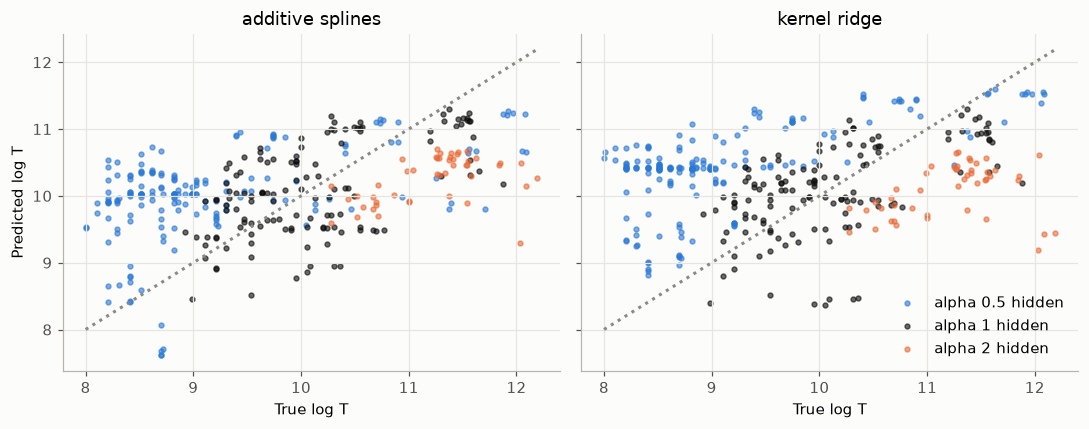

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, name in zip(axes, ['additive splines', 'kernel ridge']):
    for a in sorted(data['alpha'].unique()):
        m = data['alpha'] == a
        ax.scatter(log_T[m], pred['alpha', name][m], s=10, color=ALPHA_COLOURS[a], alpha=0.6, label=f'alpha {a:g} hidden')
    lims = [log_T.min(), log_T.max()]
    ax.plot(lims, lims, color=GREY, linestyle=':')
    ax.set_xlabel('True log T')
    ax.set_title(name)
axes[0].set_ylabel('Predicted log T')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

**Takeaway**
- On a new `alpha`, kernel ridge (0.669) and the splines (0.661) still rank runs better than the straight line (0.603).
- Only the additive splines keep R² above 0 (0.121). The squares and products in the other models shoot off when they meet values they haven't seen (R² -13.6 and -37.4).
- The plot shows why R² is poor even when the order is right. Hidden `alpha` 2 runs (orange) are predicted too early and hidden `alpha` 0.5 runs (blue) too late. Each `alpha` has its own baseline that the kernel numbers don't fully carry.

## Part 3. What shape did kernel ridge find?

We fit kernel ridge once on all grokked runs. Then we slide one number from low to high and average the prediction over every run's values of the other two. This is a **partial dependence** curve. A flat curve means the number does nothing on its own.

The additive spline curve is drawn in black for comparison. When the two curves agree, the shape doesn't depend on which model we use.

kernel ridge knobs: {'kernelridge__alpha': 0.1, 'kernelridge__gamma': 0.5}


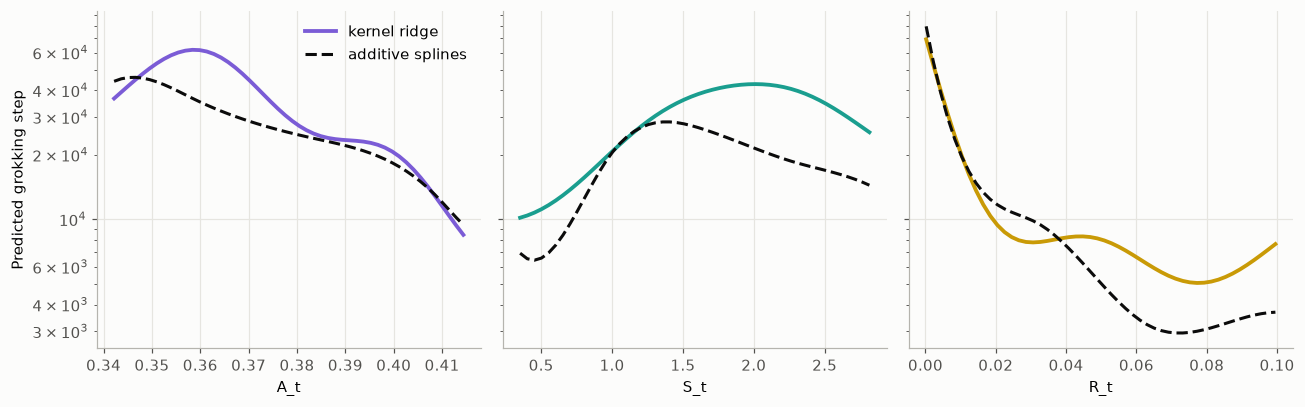

In [8]:
krr = models['kernel ridge']().fit(data[kernel], log_T, groups=data['cell'])
splines = models['additive splines']().fit(data[kernel], log_T)
print('kernel ridge knobs:', krr.regressor_.best_params_)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, number in zip(axes, kernel):
    pd_krr = partial_dependence(krr, data[kernel], [number], kind='average', grid_resolution=50, percentiles=(0.02, 0.98))
    pd_spl = partial_dependence(splines, data[kernel], [number], kind='average', grid_resolution=50, percentiles=(0.02, 0.98))
    ax.plot(pd_krr['grid_values'][0], np.exp(pd_krr['average'][0]), color=KERNEL_COLOURS[number], linewidth=2.5, label='kernel ridge')
    ax.plot(pd_spl['grid_values'][0], np.exp(pd_spl['average'][0]), color=INK, linestyle='--', label='additive splines')
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Predicted grokking step')
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

**Takeaway**
- **`R_t`**: the steepest curve. Going from 0 to 0.02 cuts the predicted step about 7 times (from about 70,000 to 10,000). After that it mostly levels off. The first bit of turning matters most.
- **`A_t`**: higher means sooner, about 4 to 6 times sooner from 0.36 to 0.41. Both models agree on the direction.
- **`S_t`**: the predicted step rises from 0.5 to about 1.4. Past that the two models disagree, since only `alpha` 0.5 runs live there. Treat the right half as unknown.
- Kernel ridge picked a fairly smooth surface (pull 0.1, width 0.5 on the scaled numbers).

## Part 4. Which number governs it?

### Leave one number out

We refit kernel ridge with one number removed and score it on hidden cells again. A big drop in R² means the other two can't stand in for the missing one.

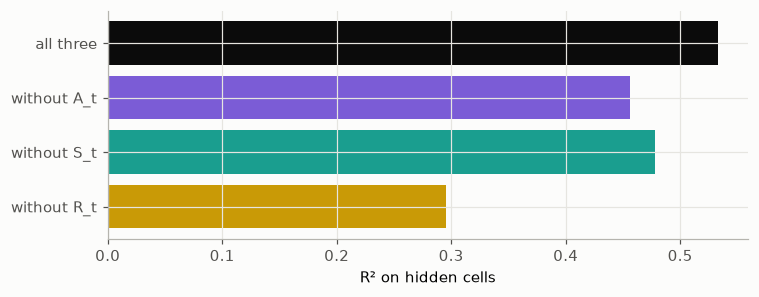

,R² on hidden cells,concordance
all three,0.533,0.792
without A_t,0.456,0.746
without S_t,0.478,0.764
without R_t,0.296,0.695


In [9]:
dropped = {'all three': kernel, 'without A_t': ['S_t', 'R_t'], 'without S_t': ['A_t', 'R_t'], 'without R_t': ['A_t', 'S_t']}
rows = {}
for name, cols in dropped.items():
    p = pd.Series(index=data.index, dtype=float)
    for group in data['cell'].unique():
        train, test = data['cell'] != group, data['cell'] == group
        model = models['kernel ridge']().fit(data.loc[train, cols], log_T[train], groups=data.loc[train, 'cell'])
        p[test] = model.predict(data.loc[test, cols])
    rows[name] = {'R² on hidden cells': r2_score(log_T, p), 'concordance': concordance_index(log_T, p)}
dropped = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(dropped.index, dropped['R² on hidden cells'], color=[INK] + [KERNEL_COLOURS[k] for k in kernel])
ax.invert_yaxis()
ax.set_xlabel('R² on hidden cells')
plt.tight_layout()
plt.show()
dropped.round(3)

### Two numbers at once

The map shows the kernel ridge prediction as `S_t` and `R_t` change together, with `A_t` held at its median. The dots are the real runs. Kernel ridge only knows the area near the dots, so the far corners are guesses.

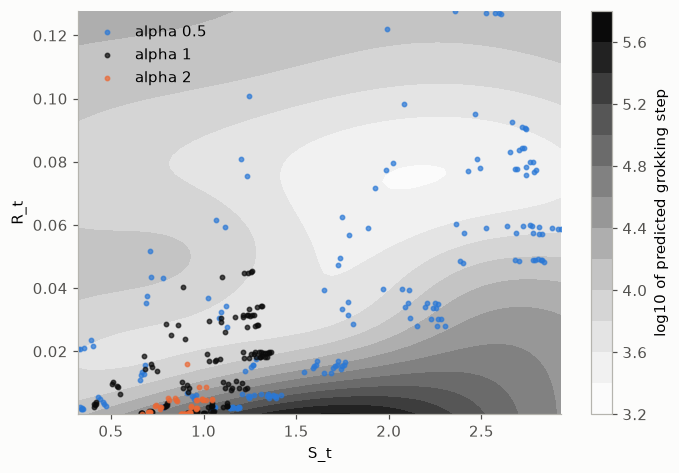

In [10]:
s_grid = np.linspace(data['S_t'].min(), data['S_t'].max(), 60)
r_grid = np.linspace(data['R_t'].min(), data['R_t'].max(), 60)
S, R = np.meshgrid(s_grid, r_grid)
probe = pd.DataFrame({'A_t': data['A_t'].median(), 'S_t': S.ravel(), 'R_t': R.ravel()})
surface = krr.predict(probe).reshape(S.shape) / np.log(10)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
im = ax.contourf(S, R, surface, levels=12, cmap='Greys')
for a, g in data.groupby('alpha'):
    ax.scatter(g['S_t'], g['R_t'], s=8, color=ALPHA_COLOURS[a], alpha=0.7, label=f'alpha {a:g}')
fig.colorbar(im, label='log10 of predicted grokking step')
ax.set_xlabel('S_t')
ax.set_ylabel('R_t')
ax.legend(loc='upper left')
ax.grid(False)
plt.tight_layout()
plt.show()

**Takeaway**
- Removing `R_t` hurts most: R² falls from 0.533 to 0.296. Removing `S_t` (0.478) or `A_t` (0.456) hurts much less. **`R_t` carries the most information the other two can't replace.**
- On the map, the latest predictions (darkest) sit at small `R_t` and large `S_t`. The earliest (lightest) need `R_t` above about 0.02. A kernel that grows a lot without turning is predicted to grok late.

## Part 5. What governs the kernel numbers themselves?

The kernel numbers come from training, and training depends on the settings. This last part asks how the settings shape `S_t` and `R_t` at the landmark. It uses all 630 runs, grokked or not. Each square is the median over the 5 seeds of a cell.

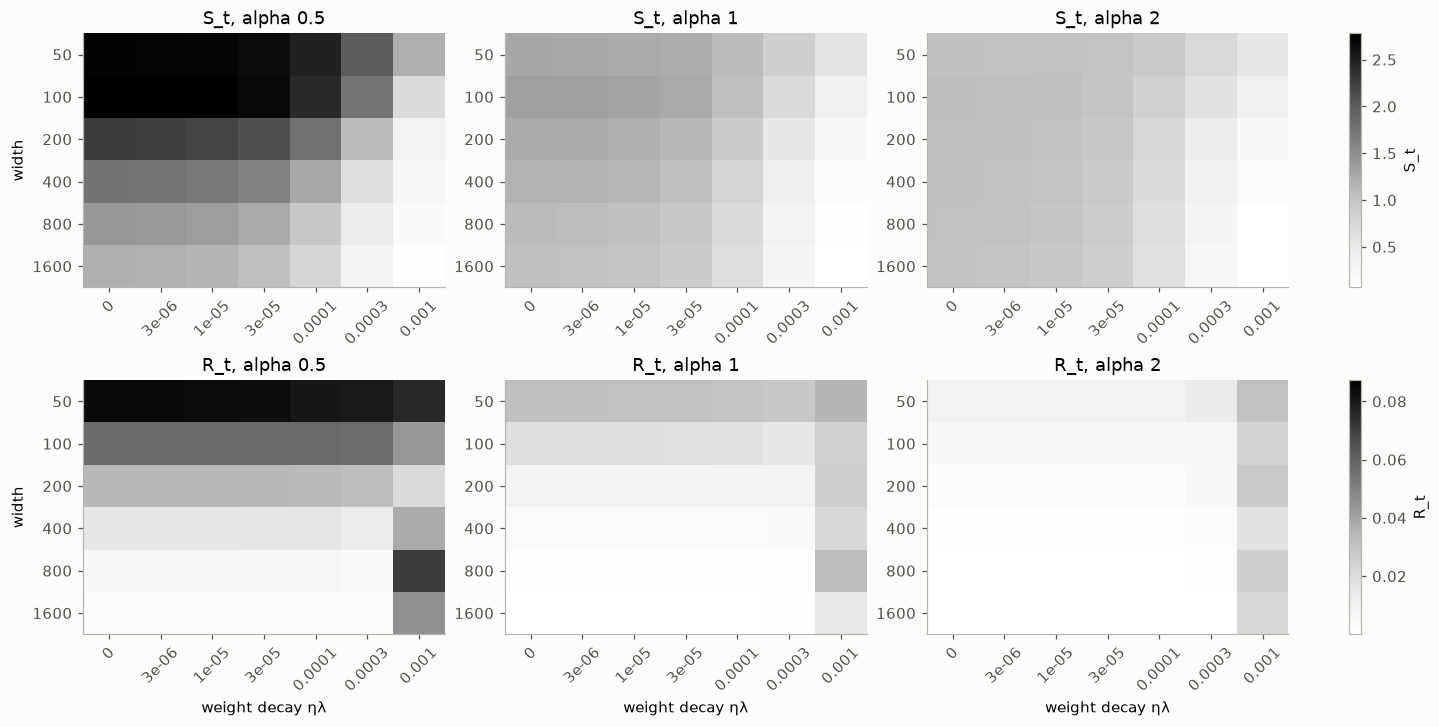

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), layout='constrained')
for row, number in enumerate(['S_t', 'R_t']):
    for ax, a in zip(axes[row], sorted(everything['alpha'].unique())):
        grid = everything[everything['alpha'] == a].pivot_table(index='width', columns='eta_kappa', values=number, aggfunc='median')
        im = ax.imshow(grid, cmap='Greys', aspect='auto',
                       vmin=everything[number].quantile(0.02), vmax=everything[number].quantile(0.98))
        ax.set_xticks(range(grid.shape[1]), [f'{w:g}' for w in grid.columns], rotation=45)
        ax.set_yticks(range(grid.shape[0]), grid.index)
        ax.set_title(f'{number}, alpha {a:g}')
        ax.grid(False)
        if a == 0.5:
            ax.set_ylabel('width')
    fig.colorbar(im, ax=axes[row], label=number)
for ax in axes[1]:
    ax.set_xlabel('weight decay ηλ')
plt.show()

How much of each number's spread do the settings explain? We fit one linear model per number, with one column for each value of `alpha`, width and weight decay.

In [12]:
dummies = pd.get_dummies(everything[['alpha', 'width', 'eta_kappa']].astype('category'), drop_first=True, dtype=float)
explained = {}
for number in kernel:
    y = np.log(everything[number])
    explained[number] = {'R² from all settings': LinearRegression().fit(dummies, y).score(dummies, y)}
    for setting in ['alpha', 'width', 'eta_kappa']:
        cols = [c for c in dummies if c.startswith(setting)]
        explained[number][f'R² from {setting} only'] = LinearRegression().fit(dummies[cols], y).score(dummies[cols], y)
pd.DataFrame(explained).T.round(3)

,R² from all settings,R² from alpha only,R² from width only,R² from eta_kappa only
A_t,0.561,0.006,0.522,0.034
S_t,0.877,0.121,0.143,0.613
R_t,0.874,0.266,0.481,0.127


**Takeaway**
- The settings explain most of `S_t` (88%) and `R_t` (87%), and about half of `A_t` (56%).
- **Weight decay governs `S_t`** (61% on its own). More weight decay shrinks the kernel. At 1e-3 `S_t` drops below 1, which means the kernel is smaller than at the start.
- **Width and `alpha` govern `R_t`** (48% and 27%). Narrow networks with small `alpha` turn their kernel most. Weight decay 1e-3 makes every network turn more.
- **Width governs `A_t`** (52%).
- So the kernel numbers are largely a readout of the settings. The 12% to 44% they don't explain is the part that could carry extra signal.

## Summary

| Question | Answer |
| --- | --- |
| Is the link curved? | Yes. Curved models explain 53% to 56% of log `T` on hidden cells, against 34% for a straight line. |
| Do the numbers interact? | Hardly. One curve per number does as well as kernel ridge. |
| What shape? | `R_t` and `A_t` lower the grokking step. `R_t` matters most just above 0. The shape of `S_t` is clear only below about 1.4. |
| Which number governs grokking? | `R_t`. Without it, R² falls from 0.53 to 0.30. |
| What governs the numbers? | The settings explain 88% of `S_t` (mostly weight decay), 87% of `R_t` (width and `alpha`) and 56% of `A_t` (width). |
| Does it carry to a new `alpha`? | The ranking does (0.66 to 0.67). The actual step doesn't, because each `alpha` has its own baseline. |

## Conclusion

The kernel numbers relate to grokking time through curves, mostly one curve per number added up. A straight line misses about a third of what the curves catch. The clearest effect is the first bit of kernel turning: runs whose kernel hasn't turned by step 2,430 grok late. The numbers themselves are mostly set by the settings, so part of what they predict is the settings showing through.

Kernel ridge here only sees runs that grokked. Notebook 3's XGBoost uses the runs that never grok as well.